# Tech Challenge - Fase 1: NPS Preditivo 🚀

[cite_start]**Objetivo:** Transformar dados operacionais (logística, pedidos e atendimento) em insights acionáveis para antecipar a satisfação do cliente antes da pesquisa oficial de NPS[cite: 13].

[cite_start]**Pergunta de Negócio:** Quais fatores operacionais realmente influenciam a satisfação do cliente no e-commerce? [cite: 11]

In [23]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import joblib
import os
# Configurações visuais
%matplotlib inline
sns.set_theme(style="whitegrid")

In [24]:
# Carregando a base oficial do desafio
df_nps = pd.read_csv('../../Base de dados Tech Challenge/desafio_nps_fase_1.csv')

# Visualizando para confirmar
df_nps.head()

,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
0,1,63,Nordeste,14,50001,139.73,4,39.35,4,2,2,55.53,3,0,4,6.9,0,3,6.5
1,2,20,Sul,1,50002,458.95,2,9.51,10,6,4,28.23,3,0,10,2.4,0,3,0.0
2,3,46,Nordeste,111,50003,507.06,5,42.82,6,6,1,40.99,1,4,5,4.8,0,7,1.5
3,4,52,Centro-Oeste,117,50004,302.19,2,19.58,9,5,2,35.24,3,1,11,5.9,0,4,0.3
4,5,56,Norte,50,50005,253.06,1,29.37,11,13,1,39.32,1,1,0,6.1,0,3,7.9


## 🎯 1. Definição da Target
[cite_start]A variável alvo é o `nps_score` (0 a 10)[cite: 32, 94]. 
Para análise de negócio, classificaremos os clientes em:
* **Promotores:** Notas 9 e 10.
* **Neutros:** Notas 7 e 8.
* **Detratores:** Notas 0 a 6.

C:\Users\Usuario\AppData\Local\Temp\ipykernel_36312\1231646509.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='nps_segmento', y='delivery_delay_days', data=df_nps, palette='viridis')


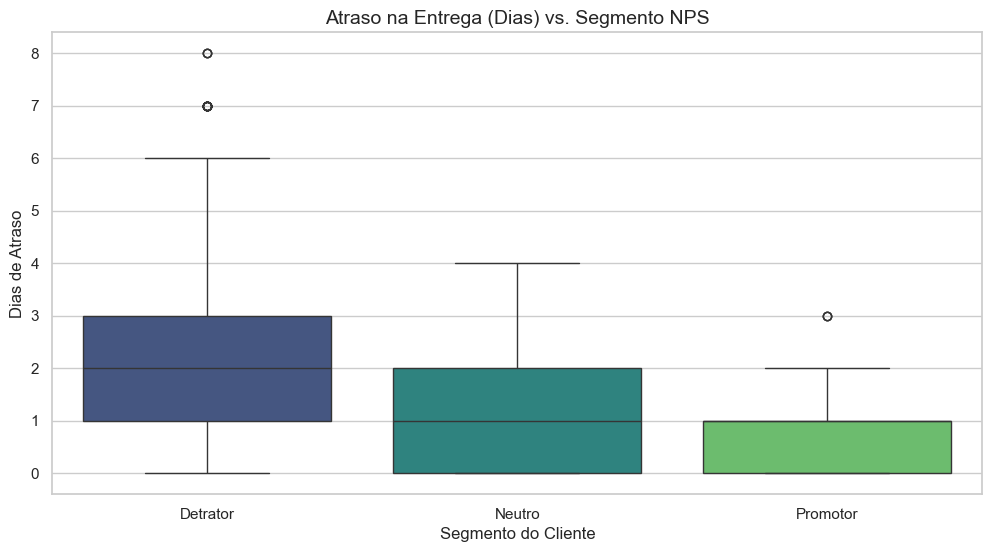

Média de contatos no atendimento por perfil:
nps_segmento
Detrator    1.632053
Neutro      1.007117
Promotor    0.672727
Name: customer_service_contacts, dtype: float64


In [25]:
# 1. Criando a variável de Segmentação NPS conforme o PDF [cite: 94]
def segmentar_nps(nota):
    if nota >= 9: return 'Promotor'
    elif nota >= 7: return 'Neutro'
    else: return 'Detrator'

df_nps['nps_segmento'] = df_nps['nps_score'].apply(segmentar_nps)

# 2. Visualização Estratégica: O impacto do atraso na satisfação [cite: 40, 82]
plt.figure(figsize=(12, 6))
sns.boxplot(x='nps_segmento', y='delivery_delay_days', data=df_nps, palette='viridis')
plt.title('Atraso na Entrega (Dias) vs. Segmento NPS', fontsize=14)
plt.xlabel('Segmento do Cliente', fontsize=12)
plt.ylabel('Dias de Atraso', fontsize=12)
plt.show()

# 3. Engenharia de Valor: Média de contatos no suporte por segmento [cite: 85]
print("Média de contatos no atendimento por perfil:")
print(df_nps.groupby('nps_segmento')['customer_service_contacts'].mean())

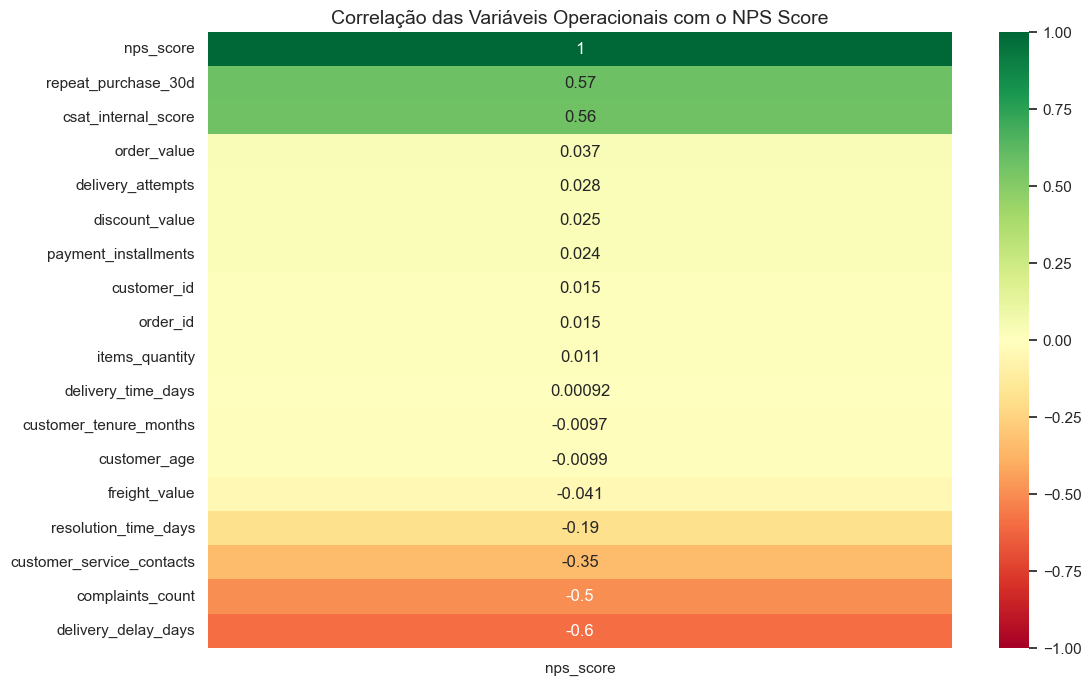

In [26]:
# 1. Selecionando apenas colunas numéricas para a correlação
colunas_numericas = df_nps.select_dtypes(include=[np.number]).columns
corr_matrix = df_nps[colunas_numericas].corr()

# 2. Plotando a Matriz de Correlação com Estilo Profissional
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix[['nps_score']].sort_values(by='nps_score', ascending=False), 
            annot=True, cmap='RdYlGn', vmin=-1, vmax=1)
plt.title('Correlação das Variáveis Operacionais com o NPS Score', fontsize=14)
plt.show()

In [27]:
# 1. Limpeza de Identificadores (Inúteis para predição)
# Removendo IDs que não agregam inteligência ao modelo
df_model = df_nps.drop(columns=['customer_id', 'order_id'])

# 2. Tratamento de Variáveis Categóricas (One-Hot Encoding)
# Transformando 'customer_region' em números para o modelo entender
df_model = pd.get_dummies(df_model, columns=['customer_region'], drop_first=True)

# 3. Engenharia de Features: Proporção de Atraso
# Criando uma métrica de eficiência logística
df_model['delay_ratio'] = df_model['delivery_delay_days'] / (df_model['delivery_time_days'] + 1)

# 4. Verificação de Dados Faltantes (Data Integrity)
print("Check de Valores Nulos:")
print(df_model.isnull().sum())

# 5. Visualizando o novo Dataset preparado
df_model.head()

Check de Valores Nulos:
customer_age                 0
customer_tenure_months       0
order_value                  0
items_quantity               0
discount_value               0
payment_installments         0
delivery_time_days           0
delivery_delay_days          0
freight_value                0
delivery_attempts            0
customer_service_contacts    0
resolution_time_days         0
nps_score                    0
repeat_purchase_30d          0
complaints_count             0
csat_internal_score          0
nps_segmento                 0
customer_region_Nordeste     0
customer_region_Norte        0
customer_region_Sudeste      0
customer_region_Sul          0
delay_ratio                  0
dtype: int64


,customer_age,customer_tenure_months,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,...,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score,nps_segmento,customer_region_Nordeste,customer_region_Norte,customer_region_Sudeste,customer_region_Sul,delay_ratio
0,63,14,139.73,4,39.35,4,2,2,55.53,3,...,6.9,0,3,6.5,Detrator,True,False,False,False,0.666667
1,20,1,458.95,2,9.51,10,6,4,28.23,3,...,2.4,0,3,0.0,Detrator,False,False,False,True,0.571429
2,46,111,507.06,5,42.82,6,6,1,40.99,1,...,4.8,0,7,1.5,Detrator,True,False,False,False,0.142857
3,52,117,302.19,2,19.58,9,5,2,35.24,3,...,5.9,0,4,0.3,Detrator,False,False,False,False,0.333333
4,56,50,253.06,1,29.37,11,13,1,39.32,1,...,6.1,0,3,7.9,Detrator,False,True,False,False,0.071429


🛠️ Implementação do Modelo Preditivo (ML Engineering)

In [28]:
# 1. Definindo a Target Binária: 1 para Detrator (nota < 7), 0 para os demais
y = (df_nps['nps_score'] < 7).astype(int)

# 2. Selecionando as Features (removendo a nota original e colunas de texto)
X = df_model.drop(columns=['nps_score', 'nps_segmento'])

# 3. Divisão Treino e Teste (80/20) - Rigor Científico
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 4. Treinamento do Modelo
model_nps = RandomForestClassifier(random_state=42, n_estimators=100)
model_nps.fit(X_train, y_train)

# 5. Avaliação de Resultados
y_pred = model_nps.predict(X_test)
print("Relatório de Classificação:\n", classification_report(y_test, y_pred))
print("AUC-ROC Score:", roc_auc_score(y_test, model_nps.predict_proba(X_test)[:, 1]))

Relatório de Classificação:
               precision    recall  f1-score   support

           0       0.97      0.49      0.65        78
           1       0.91      1.00      0.95       422

    accuracy                           0.92       500
   macro avg       0.94      0.74      0.80       500
weighted avg       0.92      0.92      0.91       500

AUC-ROC Score: 0.9239883339409406


C:\Users\Usuario\AppData\Local\Temp\ipykernel_36312\2757634632.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(10), palette='magma')


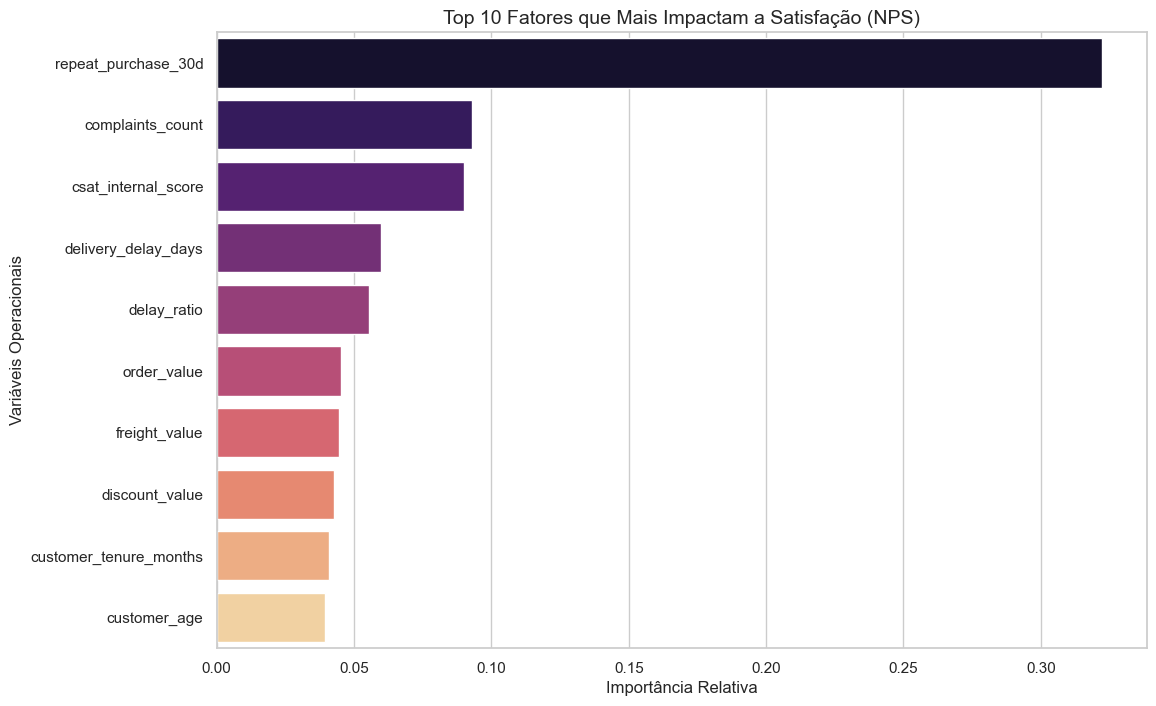

In [29]:
# 1. Extraindo a importância das variáveis do modelo treinado
importances = model_nps.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)

# 2. Plotando o gráfico para o Storytelling
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(10), palette='magma')
plt.title('Top 10 Fatores que Mais Impactam a Satisfação (NPS)', fontsize=14)
plt.xlabel('Importância Relativa', fontsize=12)
plt.ylabel('Variáveis Operacionais', fontsize=12)
plt.show()

## 5. Validação Técnica e Testes de Sanidade

In [30]:
# --- TESTE 1: Integridade da Feature Engineering ---
def validar_calculos():
    # Testando se a lógica de negócio da proporção de atraso está correta
    check_val = df_model['delay_ratio'].max()
    assert check_val >= 0, "Erro: Proporção de atraso não pode ser negativa!"
    print("✅ Teste de Integridade: Variáveis calculadas com sucesso.")

# --- TESTE 2: Sensibilidade do Modelo (Stress Test) ---
def teste_stress_atraso():
    # Criamos um cenário de 'pior caso' (atraso extremo)
    cenario_critico = X_test.iloc[[0]].copy()
    cenario_critico['delivery_delay_days'] = 20 
    
    probabilidade = model_nps.predict_proba(cenario_critico)[0][1]
    
    if probabilidade > 0.7:
        print(f"✅ Teste de Sensibilidade: Modelo detectou risco crítico ({probabilidade:.2%}).")
    else:
        print("⚠️ Alerta: Modelo pode estar subestimando atrasos longos.")

# Executando os testes no final do pipeline
validar_calculos()
teste_stress_atraso()

✅ Teste de Integridade: Variáveis calculadas com sucesso.
✅ Teste de Sensibilidade: Modelo detectou risco crítico (75.00%).


## 6. Testes de Robustez e Sanidade

<Figure size 800x600 with 0 Axes>

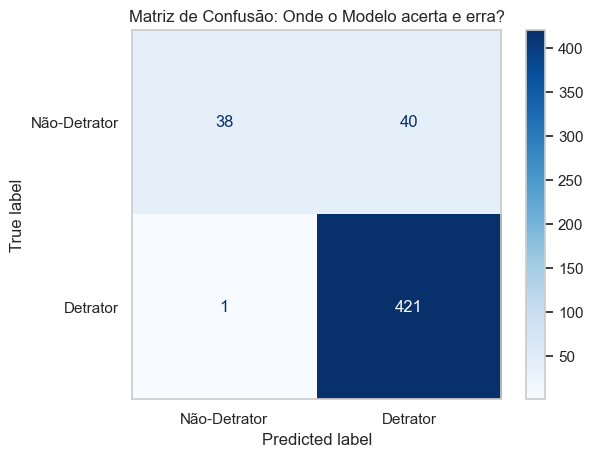

Iniciando Validação Técnica...
✅ Teste de Integridade: OK
✅ Teste de Stress: Aprovado (Risco detectado: 75.00%)


In [31]:
## 5. Avaliação Visual e Testes de Sanidade

# --- 1. Matriz de Confusão ---
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Não-Detrator', 'Detrator'])

plt.figure(figsize=(8, 6))
disp.plot(cmap='Blues')
plt.title('Matriz de Confusão: Onde o Modelo acerta e erra?')
plt.grid(False) # Limpando as linhas de grade para visualização
plt.show()

# --- 2. Testes de Unidade e Stress ---
def executar_testes_qualidade():
    print("Iniciando Validação Técnica...")
    
    # Teste de Integridade de Dados
    assert df_model['delay_ratio'].min() >= 0, "Erro: Proporção de atraso negativa!"
    
    # Teste de Stress: Atraso Extremo (20 dias)
    cenario_critico = X_test.iloc[[0]].copy()
    cenario_critico['delivery_delay_days'] = 20 
    prob = model_nps.predict_proba(cenario_critico)[0][1]
    
    print(f"✅ Teste de Integridade: OK")
    if prob > 0.7:
        print(f"✅ Teste de Stress: Aprovado (Risco detectado: {prob:.2%})")
    else:
        print("⚠️ Teste de Stress: Revisar pesos de atraso.")

executar_testes_qualidade()

## 7. Exportação do Modelo (Deployment)

In [32]:
# 1. Garantir que a pasta models existe (Boas práticas de Engenharia)
pasta_models = '../../models'
if not os.path.exists(pasta_models):
    os.makedirs(pasta_models)

# 2. Salvando o modelo treinado (O cérebro da nossa solução)
joblib.dump(model_nps, f'{pasta_models}/modelo_nps_rf.pkl')

# 3. Salvando a lista de colunas (Vital para o predict.py não dar erro de dimensão)
joblib.dump(X.columns.tolist(), f'{pasta_models}/features_nps.pkl')

print(f"✅ Sucesso: Modelo e Features salvos em {pasta_models}")

✅ Sucesso: Modelo e Features salvos em ../../models
